In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import glob
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings

DOCS_DIR  = "sample_docs"
INDEX_DIR = "faiss_index"

def load_and_split(docs_dir):
    chunks = []
    for path in glob.glob(os.path.join(docs_dir, "*.txt")):
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()
        source = os.path.basename(path)
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        current = ""
        for para in paragraphs:
            if len(current) + len(para) + 2 <= 500:
                current = (current + "\n\n" + para).strip()
            else:
                if current:
                    chunks.append(Document(page_content=current, metadata={"source": source}))
                current = para
        if current:
            chunks.append(Document(page_content=current, metadata={"source": source}))
    return chunks

chunks = load_and_split(DOCS_DIR)
print(f"{len(chunks)} chunks")

C:\Users\Mox\AppData\Local\Temp\ipykernel_20256\3651122453.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


12 chunks


In [4]:
embeddings  = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vectorstore = FAISS.from_documents(chunks, embeddings)
vectorstore.save_local(INDEX_DIR)
print(f"Index saved to {INDEX_DIR}/")

Index saved to faiss_index/


In [5]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Adds a and b."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies a and b."""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divides a by b."""
    return a / b



In [6]:
@tool
def search_docs(query: str) -> str:
    """Search the knowledge base for information about AI/ML concepts,
    LangGraph, RAG, embeddings, transformers, and related topics."""
    embeddings  = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vectorstore = FAISS.load_local(INDEX_DIR, embeddings, allow_dangerous_deserialization=True)
    docs = vectorstore.as_retriever(search_kwargs={"k": 3}).invoke(query)
    return "\n\n---\n\n".join(doc.page_content for doc in docs)

In [7]:
tools = [add, multiply, divide, search_docs]
tools_by_name = {t.name: t for t in tools}




In [8]:
from langchain_groq import ChatGroq

model = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
model_with_tools = model.bind_tools(tools)

In [9]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages:  Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [10]:
from langchain_core.messages import SystemMessage, ToolMessage

def llm_call(state: MessagesState) -> dict:
    response = model_with_tools.invoke(
        [SystemMessage(content=(
            "You are a helpful assistant that can perform arithmetic "
            "and answer questions about AI/ML concepts. "
            "Use search_docs for AI/ML questions, math tools for calculations."
        ))] + state["messages"]
    )
    return {
        "messages":  [response],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }


def tool_node(state: MessagesState) -> dict:
    results = []
    for tool_call in state["messages"][-1].tool_calls:
        t= tools_by_name[tool_call["name"]]
        observation = t.invoke(tool_call["args"])
        results.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))
    return {"messages": results}

In [11]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool_node"
    return END

In [12]:
from langgraph.graph import StateGraph, START, END


agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call",  llm_call)
agent_builder.add_node("tool_node", tool_node)


agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()

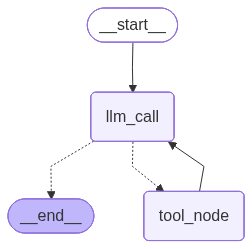

In [13]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [14]:
from langchain_core.messages import HumanMessage, AIMessage

def run_agent(question: str):
    print(f"Q: {question}")
    result = agent.invoke({"messages": [HumanMessage(content=question)], "llm_calls": 0})
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"  tool: {tc['name']}  args: {tc['args']}")
        if isinstance(msg, ToolMessage):
            print(f"  result: {msg.content[:120]}")
    print(f"A: {result['messages'][-1].content}")
    print()

In [15]:
run_agent("What is 12 times 8?")

Q: What is 12 times 8?
  tool: multiply  args: {'a': 12, 'b': 8}
  result: 96
A: 12 × 8 = **96**



In [16]:
run_agent("What is LangGraph?")

Q: What is LangGraph?
  tool: search_docs  args: {'query': 'LangGraph'}
  result: The central concept of the Transformer is the attention mechanism, particularly Self-Attention. Self-attention allows ea
  tool: search_docs  args: {'query': 'LangGraph'}
  result: The central concept of the Transformer is the attention mechanism, particularly Self-Attention. Self-attention allows ea
A: **LangGraph** is a framework developed by the LangChain team (now part of the broader LangChain ecosystem) that lets you build *state‑driven, graph‑oriented* applications powered by large language models (LLMs).  
It’s designed to make it easier to:

| Feature | What it does | Why it matters |
|---------|--------------|----------------|
| **Graph‑based workflow** | You model your application as a directed graph of *nodes* (functions, prompts, LLM calls, external APIs, etc.) and *edges* (transitions). | The flow of data and control is explicit, making complex logic easier to reason about and debug. |
| **St